# Problem statement:
Is to predict the price of a houses in a area , based on multiple other informations / variable

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

# Importing Data

* 'Avg. Area Income': Avg. Income of residents of the city house is located in.
* 'Avg. Area House Age': Avg Age of Houses in same city
* 'Avg. Area Number of Rooms': Avg Number of Rooms for Houses in same city
* 'Avg. Area Number of Bedrooms': Avg Number of Bedrooms for Houses in same city
* 'Area Population': Population of city house is located in
* 'Price': Price that the house sold at

### loading data using sklearn library

In [5]:
# reading data from sklearn lib, original data having all rows, normalized
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

print(type(data))
print(data.keys()) # acts as a python dic

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [6]:
print(data['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
 data['data']

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [8]:
data['target_names']

['MedHouseVal']

In [9]:
# making data from housing_df (sklearn variable ) , for independent variables
housing_df = pd.DataFrame(data = data['data'] , columns = data['feature_names'])

# adding target variable
housing_df[data['target_names'][0]] = data['target']

housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### loading data using file

In [10]:
# reading data from csv file, subset of original data
housing = pd.read_csv('../../data-sets/housing.csv').round(2)

In [11]:
housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81
4,59982.20,5.04,7.84,4.23,26354.11,630943.49


## EDA

In [14]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
housing_df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [11]:
housing_df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='str')

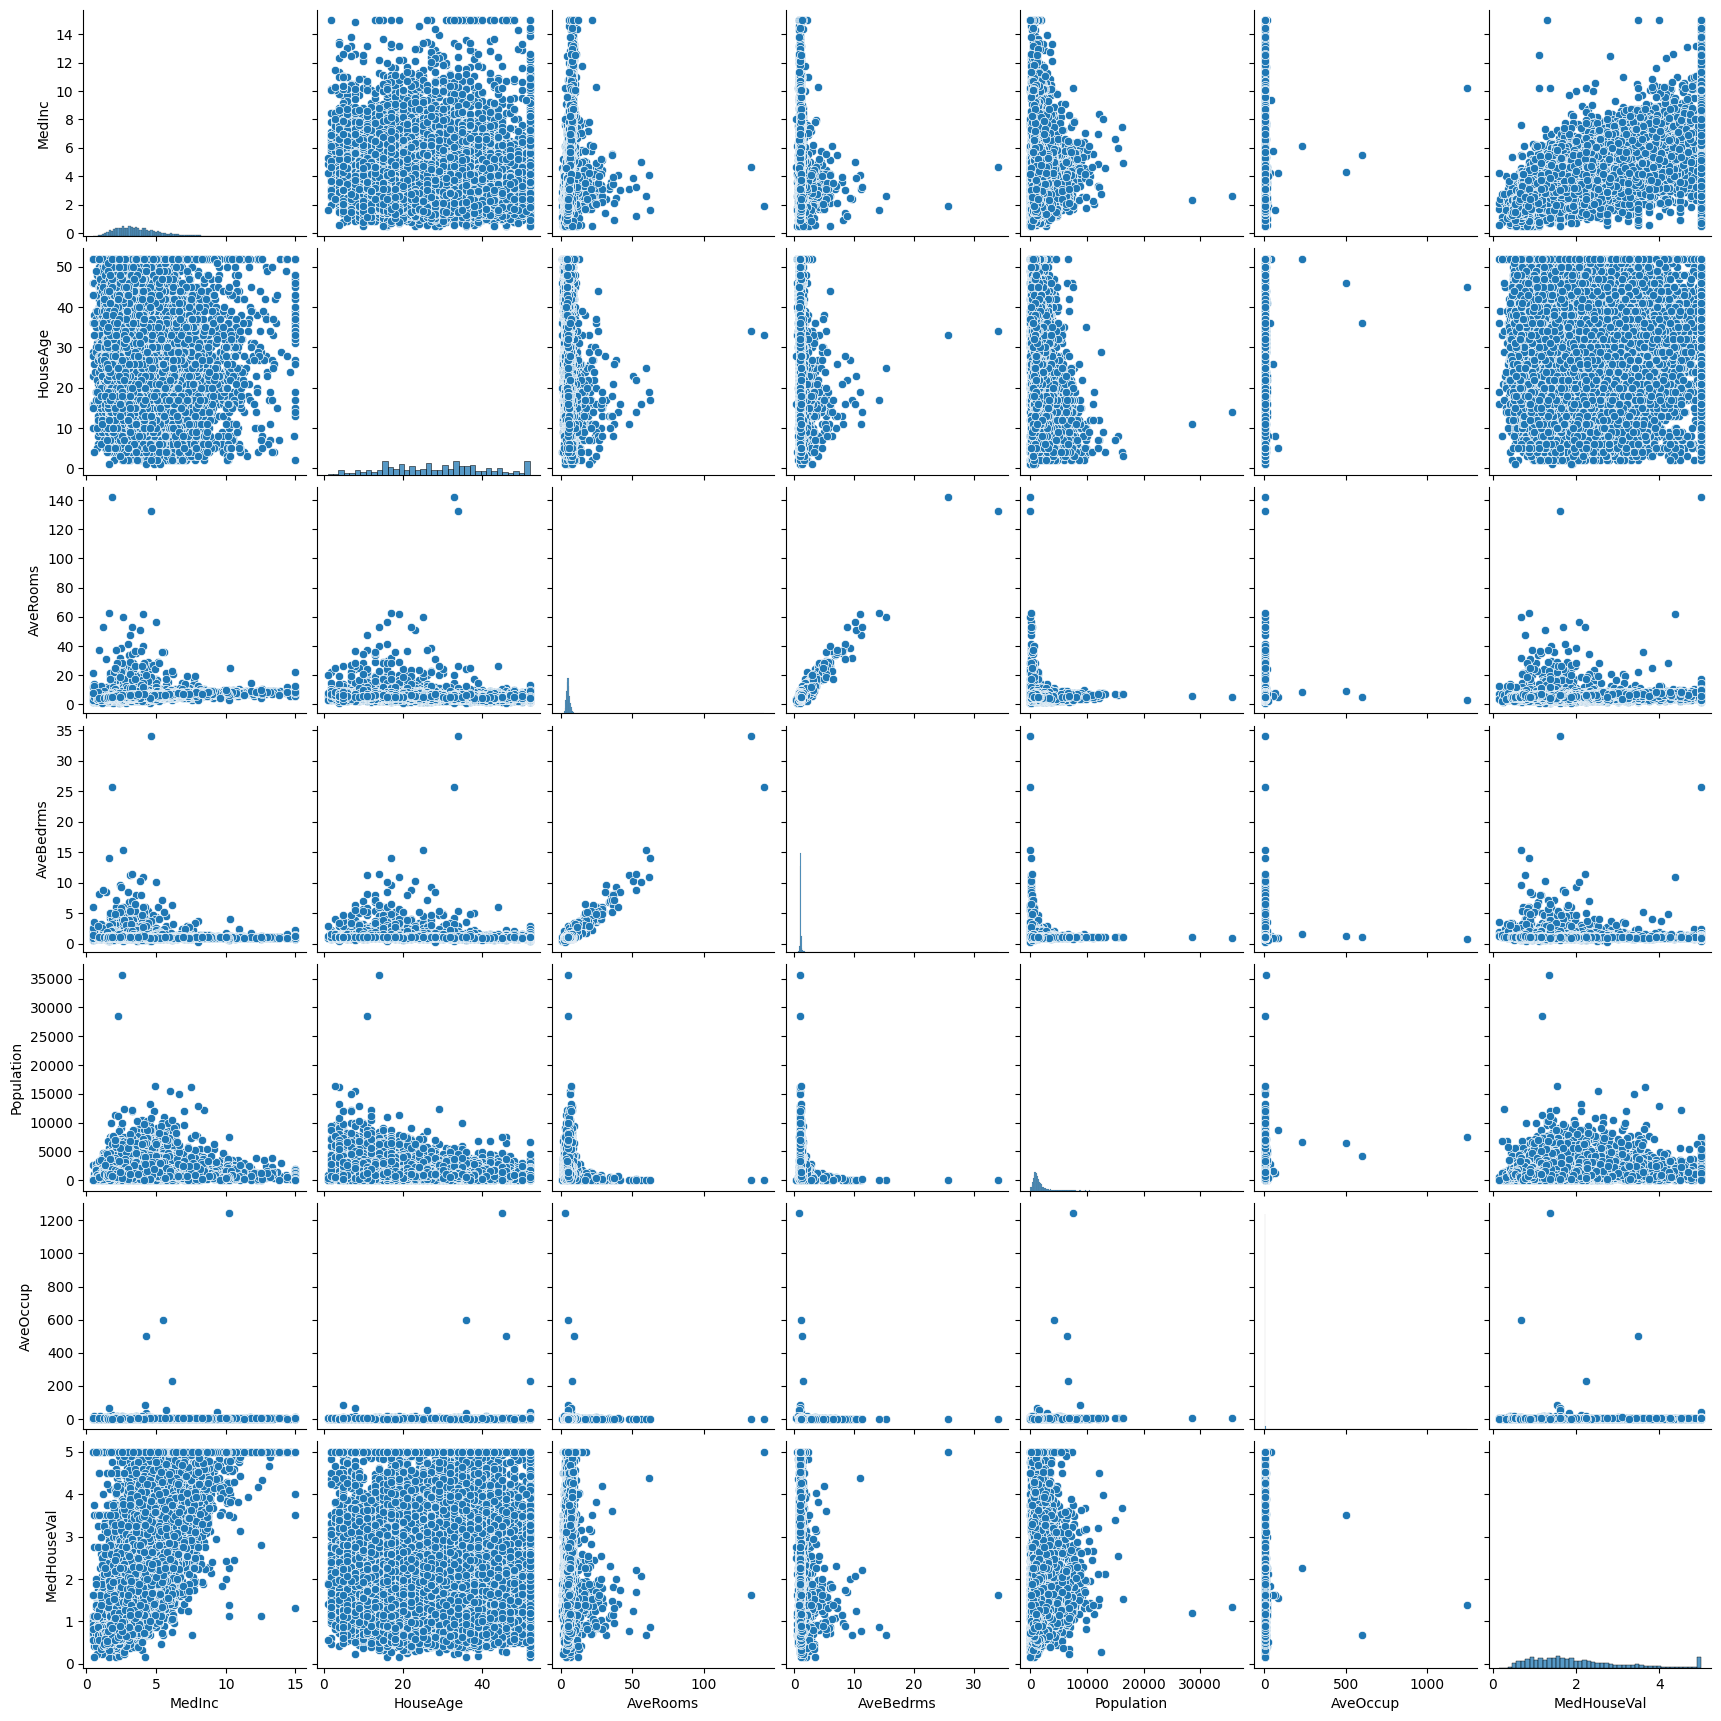

In [15]:
sns.pairplot(housing_df.drop(['Latitude', 'Longitude'], axis = 1))

In [16]:
corr = housing_df.corr()
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [17]:
corr[((corr > 0.4) | (corr < -0.4)) & (corr != 1)].fillna('')

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,,,,,,,,,0.688075
HouseAge,,,,,,,,,
AveRooms,,,,0.847621,,,,,
AveBedrms,,,0.847621,,,,,,
Population,,,,,,,,,
AveOccup,,,,,,,,,
Latitude,,,,,,,,-0.924664,
Longitude,,,,,,,-0.924664,,
MedHouseVal,0.688075,,,,,,,,


In [18]:
housing_df.drop(columns = ['AveBedrms', 'Latitude', 'Longitude'], inplace = True)

<Axes: >

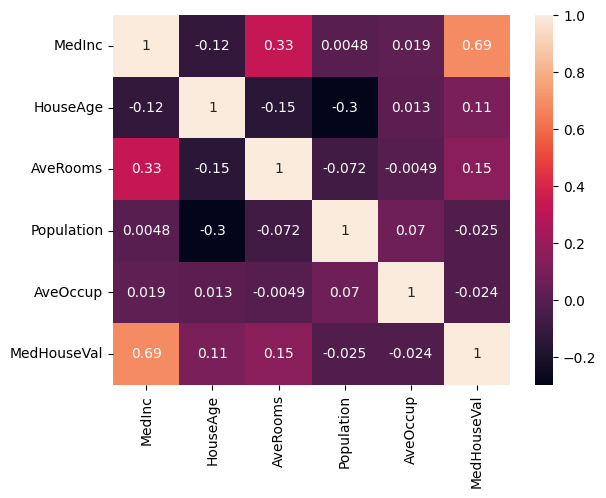

In [19]:
sns.heatmap(housing_df.corr() , annot = True)

## splitting data

### X and y arrays

In [20]:
#  MedHouseVal -> Target columns

x = housing_df.drop(['MedHouseVal'] , axis = 1)
y = housing_df['MedHouseVal']

In [21]:
x.head(5)

,MedInc,HouseAge,AveRooms,Population,AveOccup
0,8.3252,41.0,6.984127,322.0,2.555556
1,8.3014,21.0,6.238137,2401.0,2.109842
2,7.2574,52.0,8.288136,496.0,2.802260
3,5.6431,52.0,5.817352,558.0,2.547945
4,3.8462,52.0,6.281853,565.0,2.181467


In [22]:
y.head(5)

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

## Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2 , random_state = 100)

In [25]:
x_train

,MedInc,HouseAge,AveRooms,Population,AveOccup
3278,3.3929,13.0,8.580645,214.0,3.451613
16630,3.2226,11.0,4.927273,1814.0,2.748485
18748,3.3500,18.0,5.710638,1731.0,2.455319
14961,5.2741,7.0,6.855372,862.0,3.561983
1740,2.3382,19.0,4.059891,1438.0,2.609800
...,...,...,...,...,...
16304,10.0088,15.0,7.738854,1016.0,3.235669
79,2.0114,38.0,4.412903,344.0,2.219355
12119,5.6409,3.0,7.837746,8437.0,3.602477
14147,2.3812,35.0,6.289474,753.0,3.302632


In [26]:
y_train

3278     1.083
16630    1.832
18748    1.184
14961    2.494
1740     1.207
         ...  
16304    2.420
79       1.313
12119    1.977
14147    1.351
5640     2.734
Name: MedHouseVal, Length: 16512, dtype: float64

In [27]:
x_test

,MedInc,HouseAge,AveRooms,Population,AveOccup
8151,3.7031,36.0,6.276836,444.0,2.508475
53,1.2475,52.0,4.075000,1162.0,2.905000
3039,4.8266,13.0,6.746647,2170.0,3.233979
9484,2.8833,19.0,6.750000,424.0,2.789474
9307,2.8903,31.0,4.477459,2962.0,2.023224
...,...,...,...,...,...
16733,2.1154,8.0,4.288660,936.0,9.649485
5264,11.2866,14.0,7.271898,2926.0,2.669708
12374,3.3799,6.0,10.860423,4176.0,1.880234
19662,1.7227,52.0,4.954023,922.0,2.649425


In [28]:
y_test

8151     2.45300
53       1.04200
3039     1.46200
9484     1.54200
9307     3.24200
          ...   
16733    1.17200
5264     5.00001
12374    2.39300
19662    0.85700
11942    1.13900
Name: MedHouseVal, Length: 4128, dtype: float64

## Creating and Training the Model

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
lm = LinearRegression() # object oriented language

In [31]:
# training model
lm.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Evaluation

Let's evaluate the model by checking out it's coefficients and how we can interpret them.

In [32]:
# gives coefficients / slope of all the x features
lm.coef_

array([ 4.40748837e-01,  1.74965728e-02, -2.45700486e-02,  2.62336378e-05,
       -4.26907918e-03])

In [33]:
coeff_df = pd.DataFrame(lm.coef_ , index = x_train.columns , columns = ['Coefficient'])
coeff_df.round(8)

,Coefficient
MedInc,0.440749
HouseAge,0.017497
AveRooms,-0.024570
Population,0.000026
AveOccup,-0.004269


Interpreting the coefficients:

- Holding all other features fixed, a 1 unit increase in **MedInc** is associated with an increase of \$0.44 .
- Holding all other features fixed, a 1 unit increase in **HouseAge** is associated with an increase of \$0.017 .
- Holding all other features fixed, a 1 unit increase in **AveRooms** is associated with an increase of \$-0.02 .
- Holding all other features fixed, a 1 unit increase in **Population** is associated with an increase of \$0.000026 .
- Holding all other features fixed, a 1 unit increase in **AveOccup** is associated with an increase of \$-0.004269 .

In [34]:
# print the intercept
print(lm.intercept_)

-0.025044414634456835


## Predictions from our Model

Let's grab predictions off our test set and see how well it did!

In [35]:
x_test.head(5)

,MedInc,HouseAge,AveRooms,Population,AveOccup
8151,3.7031,36.0,6.276836,444.0,2.508475
53,1.2475,52.0,4.075000,1162.0,2.905000
3039,4.8266,13.0,6.746647,2170.0,3.233979
9484,2.8833,19.0,6.750000,424.0,2.789474
9307,2.8903,31.0,4.477459,2962.0,2.023224


In [36]:
predictions = lm.predict(x_test).round(2)

In [37]:
predictions

array([2.08, 1.35, 2.21, ..., 1.4 , 1.54, 2.31], shape=(4128,))

In [38]:
pred_data = pd.DataFrame({'Original' : y_test , 'Prediction by Model' : predictions})

pred_data.round(2)

,Original,Prediction by Model
8151,2.45,2.08
53,1.04,1.35
3039,1.46,2.21
9484,1.54,1.41
9307,3.24,1.75
...,...,...
16733,1.17,0.93
5264,5.00,5.08
12374,2.39,1.40
19662,0.86,1.54


## Regression Evaluation Metrics


Here are three common evaluation metrics for regression problems:

**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) is the mean of the squared errors:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Comparing these metrics:

- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

All of these are **loss functions**, because we want to minimize them.

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error , root_mean_squared_error , mean_absolute_percentage_error , r2_score 

In [40]:
print('MAE:', mean_absolute_error(y_test, predictions) )

print('MSE:', mean_squared_error(y_test, predictions) )

print('RMSE:', root_mean_squared_error(y_test, predictions))

print('MAPE:', mean_absolute_percentage_error(y_test, predictions)  * 100)

print('r2:', r2_score(y_test, predictions))

MAE: 0.5910398110465116
MSE: 0.6252124492298449
RMSE: 0.7907037683164567
MAPE: 37.26408721973332
r2: 0.5359850657499746


In [41]:
new_values = pd.DataFrame(data = [[1.2475, 52.0, 4.075000, 1162.0, 2.905000] ], columns = x_test.columns)
new_values

,MedInc,HouseAge,AveRooms,Population,AveOccup
0,1.2475,52.0,4.075,1162.0,2.905


In [42]:
lm.predict(new_values)

array([1.35257041])